# Figure 7.5-3 and Table 7.5-1 &mdash; The vapor pressure of oxygen

**Illustration 7.5-1** (*Using an Equation of State to Calculate the Vapor Pressure of
a Compound*) is the continuation of Illustration 6.4-1. Having built the
pressure&ndash;volume, pressure&ndash;enthalpy, and temperature&ndash;entropy charts
for oxygen from the Peng&ndash;Robinson equation of state in Chapter 6, we now add the
vapor&ndash;liquid phase boundary: the vapor pressure from $-200\,^\circ$C to the
critical temperature, together with the molar volume, enthalpy, and entropy of *both*
coexisting phases.

This notebook produces both deliverables of that illustration:

- **Table 7.5-1** &mdash; $Z$, $\underline V$, $\underline H$, and $\underline S$ for
  the saturated vapor and saturated liquid at each temperature, and
- **Figure 7.5-3** &mdash; the vapor pressure itself, as
  $\ln P^{\mathrm{vap}}$ against $1/T$.

The saturation calculation is the same equal-fugacity condition used for *n*-butane in
[`vapor_pressure_n_butane.ipynb`](vapor_pressure_n_butane.ipynb) (**Figure 7.5-2**),
and the enthalpy and entropy come from the departure functions of Sec. 6.4 &mdash; the
same ones used in `ch6/PR_enthalpy_O2_example.ipynb` and
`ch6/PR_entropy_O2_example.ipynb`. What is new here is putting them together *along the
saturation line*, which is what closes out the properties chart: the volumes,
enthalpies, and entropies tabulated below are exactly the two-phase envelopes drawn on
Figs. 6.4-3, 6.4-4, and 6.4-5.

Why $\ln P^{\mathrm{vap}}$ versus $1/T$? Because the Clausius&ndash;Clapeyron equation
(Eq. 7.7-6) makes that relation nearly linear, so the whole range from 0.1 bar to the
critical pressure fits on one straight line. Sec. 7.7 takes this up.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

## Properties of oxygen

Critical constants and acentric factor from SIS Table 6.6-1, exactly as in
Illustration 6.4-1: $\omega = 0.021$ is the value that gives the
$\kappa = 0.4069$ quoted there.

The **ideal-gas heat capacity** is the oxygen entry of SIS Appendix A.II,

$$ C_P^{*} = a + bT + cT^{2} + dT^{3} \qquad [\mathrm{J/(mol\,K)}] $$

with $a = 25.460$, $b \times 10^{2} = 1.519$, $c \times 10^{5} = -0.715$,
$d \times 10^{9} = 1.311$.

> **Two things to be aware of about this $C_P^{*}$.**
>
> 1. Appendix A.II gives its validity range as **273&ndash;1800 K**, and this
>    illustration uses it from **73 K** &mdash; a 200 K extrapolation below the fitted
>    range. The ideal-gas part of $\underline H$ and $\underline S$
>    here rests on an extrapolated correlation. The *departure* functions, which carry
>    all the real-fluid physics, are unaffected.
> 2. These are **not** the coefficients in `code/data/pure_property.csv`, which carries
>    the Reid&ndash;Prausnitz&ndash;Poling set $(28.11,\ -3.68\times10^{-6},\
>    1.746\times10^{-5},\ -1.065\times10^{-8})$ for oxygen. Over 73&ndash;298 K the two
>    differ by up to 152 J/mol in $\underline H$ and 1.2 J/(mol&middot;K) in
>    $\underline S$ &mdash; so which set you use is a real choice, not a rounding
>    detail. Appendix A.II is the book's own tabulation and is what every $\underline H$
>    and $\underline S$ in this chapter is built on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import constants
from scipy.optimize import brentq
from numpy.polynomial import Polynomial

# Typography, matching the other recomputed figures (Figs. 6.6-1, 7.3-1 to 7.3-4): use a
# real LaTeX installation when there is one, so the figure is set in Computer Modern like
# the book, and fall back to matplotlib's own mathtext otherwise — the notebook still runs
# in Colab, which has no TeX. The fallback keeps a serif face and CM math.
from shutil import which

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math for the no-TeX fallback
    "pdf.fonttype": 42,         # keep text as text in the PDF
    "ps.fonttype": 42,
})

R = constants.R      # gas constant, J/(mol K)
BAR = 1e5            # Pa per bar
TO_KELVIN = 273.15
SQRT2 = np.sqrt(2.0)

# oxygen — SIS Table 6.6-1
Tc = 154.6           # K
Pc = 5.046e6         # Pa
omega = 0.021        # acentric factor

# ideal-gas heat capacity, SIS Appendix A.II (J/(mol K); fitted 273-1800 K)
cA, cB, cC, cD = 25.460, 1.519e-2, -0.715e-5, 1.311e-9

# reference state of Illustration 6.4-1: the ideal gas at 25 C and 1 bar
T_REF, P_REF = 298.15, 1e5

kappa = 0.37464 + 1.54226 * omega - 0.26992 * omega**2
print(f"oxygen: Tc = {Tc} K ({Tc-TO_KELVIN:.2f} C), Pc = {Pc/BAR:.3f} bar, "
      f"omega = {omega}")
print(f"kappa  = {kappa:.4f}   (the value quoted in Illustration 6.4-1)")
print(f"Cp*(25 C) = {cA + cB*T_REF + cC*T_REF**2 + cD*T_REF**3:.2f} J/(mol K)")
print(f"LaTeX typesetting: {'on (Computer Modern)' if mpl.rcParams['text.usetex'] else 'off (mathtext fallback)'}")

oxygen: Tc = 154.6 K (-118.55 C), Pc = 50.460 bar, omega = 0.021
kappa  = 0.4069   (the value quoted in Illustration 6.4-1)
Cp*(25 C) = 29.39 J/(mol K)
LaTeX typesetting: on (Computer Modern)


## The Peng&ndash;Robinson equation of state, and its departure functions

$$ P = \frac{RT}{\underline{V}-b} -
   \frac{a(T)}{\underline{V}(\underline{V}+b) + b(\underline{V}-b)} \tag{Eq. 6.4-2}$$

$$ b = 0.07780\,\frac{RT_c}{P_c}, \qquad
   a(T) = 0.45724\,\frac{R^{2}T_c^{2}}{P_c}\,\alpha(T), \qquad
   \sqrt{\alpha} = 1 + \kappa\left(1-\sqrt{T/T_c}\right) $$

In terms of $Z = P\underline V/RT$ (SIS Table 6.4-3),

$$ Z^{3} + (B-1)Z^{2} + (A - 3B^{2} - 2B)Z + (-AB + B^{2} + B^{3}) = 0,
   \qquad A = \frac{aP}{(RT)^{2}}, \quad B = \frac{bP}{RT} $$

Below $T_c$ this cubic has three real roots; the smallest is the liquid and the largest
the vapor. Writing
$\Lambda(Z,B) = \ln\!\big[(Z+(1+\sqrt2)B)/(Z+(1-\sqrt2)B)\big]$, the three quantities
we need are the fugacity coefficient and the enthalpy and entropy departures:

$$ \ln\frac{f}{P} = (Z-1) - \ln(Z-B) - \frac{A}{2\sqrt{2}B}\,\Lambda(Z,B) $$

$$ \underline H - \underline H^{IG} = RT(Z-1)
   + \frac{T\,\mathrm{d}a/\mathrm{d}T - a}{2\sqrt{2}\,b}\,\Lambda(Z,B) \tag{Eq. 6.4-29}$$

$$ \underline S - \underline S^{IG} = R\ln(Z-B)
   + \frac{\mathrm{d}a/\mathrm{d}T}{2\sqrt{2}\,b}\,\Lambda(Z,B) \tag{Eq. 6.4-30}$$

$$ \frac{\mathrm{d}a}{\mathrm{d}T}
   = -0.45724\,\frac{R^{2}T_c^{2}}{P_c}\,
     \frac{\kappa\sqrt{\alpha}}{\sqrt{T\,T_c}} $$

In [2]:
def calc_b():
    return 0.07780 * R * Tc / Pc


def calc_a(T):
    return 0.45724 * R**2 * Tc**2 / Pc * (1 + kappa * (1 - np.sqrt(T / Tc)))**2


def calc_dadT(T):
    """da/dT — needed only by the enthalpy and entropy departures."""
    sqrtalpha = 1 + kappa * (1 - np.sqrt(T / Tc))
    return -0.45724 * R**2 * Tc**2 / Pc * kappa * sqrtalpha / np.sqrt(T * Tc)


def PR_pressure(V, T):
    a, b = calc_a(T), calc_b()
    return R * T / (V - b) - a / (V * (V + b) + b * (V - b))


def PR_Z(P, T):
    """Real compressibility roots (ascending), with A and B."""
    a, b = calc_a(T), calc_b()
    A, B = a * P / (R * T)**2, b * P / (R * T)
    roots = Polynomial([-A * B + B**2 + B**3, A - 3 * B**2 - 2 * B, -1 + B, 1]).roots()
    # tolerance scaled to root magnitude: near Tc the roots crowd together and pick up
    # tiny numerical imaginary parts that a fixed tolerance would reject
    keep = np.abs(roots.imag) < 1e-9 * np.maximum(1.0, np.abs(roots.real))
    return np.sort(roots.real[keep]), A, B


def log_term(Z, B):
    return np.log((Z + (1 + SQRT2) * B) / (Z + (1 - SQRT2) * B))


def PR_lnphi(Z, A, B):
    return (Z - 1) - np.log(Z - B) - A / (2 * SQRT2 * B) * log_term(Z, B)


def departure_H(T, Z, A, B):
    """H - H_ideal-gas at (T, P), J/mol (SIS Eq. 6.4-29)."""
    a, b, dadT = calc_a(T), calc_b(), calc_dadT(T)
    return R * T * (Z - 1) + (T * dadT - a) / (2 * SQRT2 * b) * log_term(Z, B)


def departure_S(T, Z, A, B):
    """S - S_ideal-gas at (T, P), J/(mol K) (SIS Eq. 6.4-30)."""
    b, dadT = calc_b(), calc_dadT(T)
    return R * np.log(Z - B) + dadT / (2 * SQRT2 * b) * log_term(Z, B)


def H_ideal(T):
    """Ideal-gas enthalpy relative to T_REF, J/mol."""
    return (cA * (T - T_REF) + cB / 2 * (T**2 - T_REF**2)
            + cC / 3 * (T**3 - T_REF**3) + cD / 4 * (T**4 - T_REF**4))


def S_ideal(T, P):
    """Ideal-gas entropy relative to (T_REF, P_REF), J/(mol K)."""
    return (cA * np.log(T / T_REF) + cB * (T - T_REF)
            + cC / 2 * (T**2 - T_REF**2) + cD / 3 * (T**3 - T_REF**3)
            - R * np.log(P / P_REF))


# Sanity check on the reference state: H and S are defined to be zero for the IDEAL gas
# at 25 C and 1 bar, and oxygen there is very nearly — but not quite — ideal. Both
# should therefore come out small, and their size is the departure of real oxygen from
# ideality at ambient conditions.
Z0, A0, B0 = PR_Z(P_REF, T_REF)
Z0 = Z0[Z0 > B0].max()
print(f"H(25 C, 1 bar) = {H_ideal(T_REF) + departure_H(T_REF, Z0, A0, B0):>8.2f} J/mol")
print(f"S(25 C, 1 bar) = {S_ideal(T_REF, P_REF) + departure_S(T_REF, Z0, A0, B0):>8.4f}"
      f" J/(mol K)")

H(25 C, 1 bar) =    -9.45 J/mol
S(25 C, 1 bar) =  -0.0240 J/(mol K)


## The saturation line

At each temperature the vapor pressure is the pressure at which the liquid and vapor
fugacities are equal, $f^{\mathrm{L}} = f^{\mathrm{V}}$ &mdash; the calculation of
Sec. 7.4, and the algorithm of the Fig. 7.5-1 flow sheet.

As in the *n*-butane notebook we **bracket** the root between the two spinodal
pressures (the local maximum and minimum of the sub-critical isotherm) rather than
guessing a starting pressure. Three real roots exist only inside that interval, so the
bracket cannot converge on the *trivial solution* &mdash; the one-phase answer Sec. 7.5
warns about, where the "liquid" and "vapor" come back identical. That matters more here
than for *n*-butane: this table runs to within 1.5 K of $T_c$, where the loop has
almost closed.

In [3]:
def spinodal_bounds(T, n=20000):
    """Pressures at the local max and min of the sub-critical isotherm loop.
    Returns None once the loop has vanished (T >= Tc)."""
    b = calc_b()
    V = np.logspace(np.log10(1.0000001 * b), 3.0, n)
    P = PR_pressure(V, T)
    turns = np.where(np.diff(np.sign(np.diff(P))) != 0)[0]
    if len(turns) < 2:
        return None
    return P[turns].min(), P[turns].max()


def fugacity_residual(T, P):
    """ln(f_L/P) - ln(f_V/P); NaN if the cubic has no two distinct phase roots."""
    Z, A, B = PR_Z(P, T)
    Z = Z[Z > B]
    if len(Z) < 2:
        return np.nan
    return PR_lnphi(Z.min(), A, B) - PR_lnphi(Z.max(), A, B)


def Psat(T):
    """Vapor pressure (Pa) at T (K), bracketed between the spinodals."""
    bounds = spinodal_bounds(T)
    if bounds is None:
        return None
    P_lo, P_hi = bounds
    P_lo = max(P_lo, 1e-10 * BAR)          # the vapor spinodal pressure can be negative
    for _ in range(200):
        r_lo, r_hi = fugacity_residual(T, P_lo), fugacity_residual(T, P_hi)
        if np.isfinite(r_lo) and np.isfinite(r_hi) and r_lo * r_hi < 0:
            break
        if not np.isfinite(r_lo):
            P_lo *= 1.5
        if not np.isfinite(r_hi):
            P_hi *= 0.999
        if P_hi <= P_lo:
            return None
    else:
        return None
    return brentq(lambda P: fugacity_residual(T, P), P_lo, P_hi,
                  xtol=1e-12, rtol=1e-12)


def saturation_properties(T):
    """All of Table 7.5-1 for one temperature. Volumes in m^3/kmol (= L/mol),
    H in J/mol, S in J/(mol K)."""
    P = Psat(T)
    Z, A, B = PR_Z(P, T)
    Z = Z[Z > B]
    ZL, ZV = Z.min(), Z.max()
    out = {"T_C": T - TO_KELVIN, "T": T, "P": P / BAR}
    for tag, Zx in (("V", ZV), ("L", ZL)):
        out[f"Z{tag}"] = Zx
        out[f"V{tag}"] = Zx * R * T / P * 1e3
        out[f"H{tag}"] = H_ideal(T) + departure_H(T, Zx, A, B)
        out[f"S{tag}"] = S_ideal(T, P) + departure_S(T, Zx, A, B)
    return out


# Sanity check at the normal boiling point of oxygen (90.2 K), where the answer should
# be one atmosphere. The ~2% miss is the equation of state's own accuracy, not a bug:
# kappa(omega) is a correlation, and oxygen sits at Tr = 0.58 here.
Tb = 90.2
print(f"Psat({Tb} K) = {saturation_properties(Tb)['P']:.4f} bar   "
      f"(measured 1 atm = {constants.atm/BAR:.4f} bar)")

Psat(90.2 K) = 1.0327 bar   (measured 1 atm = 1.0132 bar)


## Table 7.5-1

Eleven temperatures from $-200\,^\circ$C up to $-120\,^\circ$C, the last of these only
1.45 K below the critical temperature. Volumes are in m$^3$/kmol (the units of the
Fig. 6.4-3 abscissa, and the same as L/mol), enthalpies in J/mol, entropies in
J/(mol&middot;K).

In [4]:
T_TABLE_C = [-200, -190, -180, -175, -170, -160, -150, -140, -130, -125, -120]

table = pd.DataFrame([saturation_properties(TC + TO_KELVIN) for TC in T_TABLE_C])

show = table[["T_C", "P", "ZV", "ZL", "VV", "VL", "HV", "HL", "SV", "SL"]].copy()
show.columns = ["T (C)", "P (bar)", "Z vap", "Z liq", "V vap", "V liq",
                "H vap", "H liq", "S vap", "S liq"]
print(show.to_string(index=False, formatters={
    "T (C)": "{:.0f}".format, "P (bar)": "{:.2f}".format,
    "Z vap": "{:.4f}".format, "Z liq": "{:.4f}".format,
    "V vap": "{:.4f}".format, "V liq": "{:.4f}".format,
    "H vap": "{:.2f}".format, "H liq": "{:.2f}".format,
    "S vap": "{:.2f}".format, "S liq": "{:.2f}".format}))

T (C) P (bar)  Z vap  Z liq   V vap  V liq    H vap     H liq  S vap   S liq
 -200    0.11 0.9945 0.0004 53.3991 0.0232 -6311.13 -13492.98 -20.86 -119.04
 -190    0.47 0.9832 0.0016 14.5886 0.0241 -6064.93 -13013.90 -29.34 -112.91
 -180    1.39 0.9611 0.0045  5.3654 0.0252 -5842.65 -12518.24 -35.64 -107.31
 -175    2.19 0.9452 0.0069  3.5172 0.0259 -5744.83 -12261.71 -38.25 -104.65
 -170    3.31 0.9256 0.0103  2.3977 0.0266 -5658.45 -11997.73 -40.60 -102.05
 -160    6.75 0.8747 0.0204  1.2182 0.0284 -5528.91 -11440.84 -44.74  -96.99
 -150   12.29 0.8063 0.0371  0.6717 0.0309 -5475.75 -10829.71 -48.48  -91.96
 -140   20.53 0.7171 0.0641  0.3866 0.0346 -5533.85 -10132.33 -52.19  -86.73
 -130   32.14 0.5985 0.1107  0.2216 0.0410 -5779.81  -9274.35 -56.43  -80.84
 -125   39.42 0.5194 0.1500  0.1623 0.0469 -6042.11  -8716.88 -59.18  -77.23
 -120   47.81 0.4019 0.2255  0.1070 0.0601 -6589.67  -7881.69 -63.55  -71.99


## Figure 7.5-3

The printed figure has an unusual and rather nice set of axes, reproduced here:

- the abscissa is $1/T \times 10^{2}$, from 0.6 to 1.4 (i.e. $T$ from 167 K down to
  71 K);
- the **left** ordinate is $\ln P^{\mathrm{vap}}$, linear from $-3$ to 4, so
  Clausius&ndash;Clapeyron linearity shows up as a straight line;
- the **right** ordinate is the *same axis* relabeled in $P^{\mathrm{vap}}$ itself,
  so the pressure can be read off directly without exponentiating;
- a second abscissa across the top carries $T$ in kelvin.

The curve runs from $-200\,^\circ$C to the critical point.

> Two label errata in the printed figures, corrected here: the printed abscissa reads
> `1/T (K) x 10²` and the printed Fig. 7.5-2 abscissa reads `1000/T (K)`. The units of
> $1/T$ are **K$^{-1}$**.

A high-resolution PDF is written to `pdf/Fig_7.5-3.pdf`.

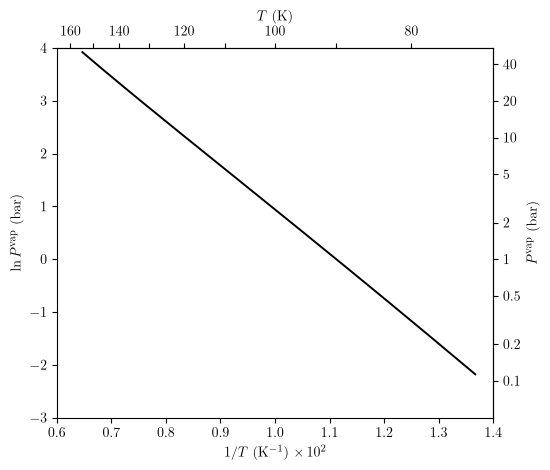

In [5]:
import os
from matplotlib.ticker import FixedLocator

INV_LO, INV_HI = 0.6, 1.4          # 1/T x 10^2, matching the printed figure
LNP_LO, LNP_HI = -3.0, 4.0         # ln Pvap, matching the printed figure
T_LO = -200 + TO_KELVIN            # 73.15 K, the low end of Illustration 7.5-1
BLACK = "black"

# the saturation curve, on a grid uniform in the plotting variable 1/T
inv = np.linspace(1e2 / (0.9999 * Tc), 1e2 / T_LO, 300)
P_curve = np.array([Psat(1e2 / x) or np.nan for x in inv]) / BAR

# aspect ratio and axes limits match Fig. 7.5-3 as printed
fig, ax = plt.subplots(figsize=(5.6, 4.8))
ax.plot(inv, np.log(P_curve), "-", color=BLACK, lw=1.4)

ax.set_xlim(INV_LO, INV_HI)
ax.set_ylim(LNP_LO, LNP_HI)
ax.set_xticks(np.arange(0.6, 1.45, 0.1))
ax.set_yticks(np.arange(-3, 5, 1))
ax.set_xlabel(r"$1/T$  (K$^{-1}$) $\times\, 10^{2}$")
ax.set_ylabel(r"$\ln P^{\mathrm{vap}}$  (bar)")

# --- right ordinate: the same axis, relabelled in Pvap itself ---
right = ax.secondary_yaxis("right", functions=(lambda y: y, lambda y: y))
P_ticks = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 40]
right.yaxis.set_major_locator(FixedLocator(np.log(P_ticks)))
right.set_yticklabels([f"{p:g}" for p in P_ticks])
right.set_ylabel(r"$P^{\mathrm{vap}}$  (bar)")

# --- second abscissa: temperature itself, at 1/T x 10^2 positions ---
top = ax.secondary_xaxis("top", functions=(lambda x: x, lambda x: x))
T_ticks = np.arange(80, 170, 10)
top.xaxis.set_major_locator(FixedLocator(1e2 / T_ticks))
# the book labels every other tick (160, 140, 120, 100, 80)
top.set_xticklabels([f"{t}" if t % 20 == 0 else "" for t in T_ticks])
top.set_xlabel(r"$T$  (K)")

os.makedirs("pdf", exist_ok=True)
plt.tight_layout()
plt.savefig("pdf/Fig_7.5-3.pdf", dpi=300, bbox_inches="tight")
plt.show()

## What the figure and table show

**The line is very nearly straight, but not quite.** Over four decades of pressure the
Peng&ndash;Robinson vapor pressure is almost exactly linear in $1/T$, which is
Eq. 7.7-6 with a constant enthalpy of vaporization. The gentle downward curvature near
the critical point (left end) is the physics the straight line misses:
$\Delta^{\mathrm{vap}}\underline{H}$ is not constant, and it must vanish at $T_c$.

**The table is what closes the properties chart.** Below $T_c$ the cubic returns three
roots, and Illustration 7.5-2 explains the rule for choosing between them: compare the
system pressure with the vapor pressure computed here &mdash; above it the liquid root
is stable, below it the vapor root. Without the saturation line there is no way to
resolve that ambiguity, which is why Chapter 6's charts could not be finished in
Chapter 6.

**Watch the two phases converge.** From $-200\,^\circ$C to $-120\,^\circ$C the vapor
compressibility falls from 0.994 to about 0.4 while the liquid's rises from 0.0004, and
the molar volumes close from a factor of 2000 apart to a factor of a few. The two
$\underline H$ and $\underline S$ columns converge the same way: their differences are
$\Delta^{\mathrm{vap}}\underline{H}$ and $\Delta^{\mathrm{vap}}\underline{S}$, and both
go to zero at the critical point.

### Things to try

1. Compute $\Delta^{\mathrm{vap}}\underline{H} = \underline H^{V} - \underline H^{L}$
   from the table and plot it against $T$. Confirm it heads to zero at $T_c$, and
   compare its low-temperature value with the slope of the line in Figure 7.5-3 via
   Eq. 7.7-6.
2. Check the thermodynamic consistency of the table: at each temperature
   $\Delta^{\mathrm{vap}}\underline{H}$ should equal
   $T\,\Delta^{\mathrm{vap}}\underline{S}$, because the two phases are in equilibrium.
   How well does the table satisfy it, and why is it not exact?
3. Add the saturation envelope to the Chapter 6 charts: take `VL`/`VV` into
   `ch6/PR_isotherms_O2_example.ipynb` (Fig. 6.4-3), and `HL`/`HV`, `SL`/`SV` into the
   enthalpy and entropy notebooks (Figs. 6.4-4 and 6.4-5). This is the last sentence of
   Illustration 7.5-1. **Note** those notebooks use the
   Reid&ndash;Prausnitz&ndash;Poling $C_P^{*}$ rather than Appendix A.II, so their
   $\underline H$ and $\underline S$ are on a slightly different footing than this
   table &mdash; reconcile the heat capacity first.
4. Re-run the table with the `thermo` package instead of the routines above:
   `PengRobinson.from_database("oxygen")` provides `vapor_pressure`, `departure_H`, and
   `departure_S` directly, and the whole table becomes a loop of three calls. The
   numbers will shift slightly, because `from_database` takes its $C_P^{*}$ from
   `code/data/pure_property.csv` — see the warning at the top.
5. Repeat the illustration for nitrogen (Problem 7.33) or water (Problem 7.34), which
   ask for exactly these tables and charts for another fluid.